In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("financekim/curated-cxr-report-generation-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/curated-cxr-report-generation-dataset


In [4]:
# 📦 Step 1: Import libraries
import pandas as pd
import numpy as np
import re
import nltk
import os

from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# NLTK downloads (only run once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
# 📂 Step 2: Load CSV Files
train_path = "/kaggle/input/curated-cxr-report-generation-dataset/Cleanses csv tfrecords/df_train.csv"
val_path = "/kaggle/input/curated-cxr-report-generation-dataset/Cleanses csv tfrecords/df_val.csv"

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)

# Combine train and val for full preprocessing
df = pd.concat([df_train, df_val], ignore_index=True)

print("Shape:", df.shape)
df.head()


Shape: (95232, 3)


,id,text,path
0,s50260386,A tip of a left Port-A-Cath lies in the low su...,../input/curated-cxr-report-generation-dataset...
1,s58019009,"AP chest compared to ___, 9:04 a.m.: In place ...",../input/curated-cxr-report-generation-dataset...
2,s54123565,"AP chest compared to ___, read in conjunction ...",../input/curated-cxr-report-generation-dataset...
3,s51811896,A tracheostomy cannula is located within the u...,../input/curated-cxr-report-generation-dataset...
4,s59641633,Bilateral previous mentioned reticular opaciti...,../input/curated-cxr-report-generation-dataset...


In [6]:
# 🧹 Step 3: Clean Text Function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)


In [7]:
# ✅ Step 4: Apply Cleaning on `impression` Column
# Check which column exists: 'impression' or 'Report_Impression'?
df.columns


Index(['id', 'text', 'path'], dtype='object')

In [8]:

df['clean_impression'] = df['text'].apply(clean_text)


In [9]:
# 🏷️ Step 5: Define Disease Keywords
disease_keywords = {
    'pneumonia': ['pneumonia', 'consolidation'],
    'cardiomegaly': ['cardiomegaly', 'enlarged heart'],
    'pleural_effusion': ['effusion', 'pleural fluid'],
    'atelectasis': ['atelectasis'],
    'edema': ['edema'],
    'infiltration': ['infiltrate', 'infiltration'],
    'nodule': ['nodule', 'mass', 'lesion'],
    'opacity': ['opacity']
}


In [10]:
# 🧠 Step 6: Create Labels from Keywords
def extract_labels(text, keyword_dict):
    labels = {}
    for disease, terms in keyword_dict.items():
        found = any(term in text for term in terms)
        labels[disease] = int(found)
    return pd.Series(labels)

label_df = df['clean_impression'].apply(lambda x: extract_labels(x, disease_keywords))
df = pd.concat([df, label_df], axis=1)


In [11]:
# 📊 Step 7: Check Label Distribution
print("Label distribution:\n", df[list(disease_keywords.keys())].sum())


Label distribution:
 pneumonia           33283
cardiomegaly        15758
pleural_effusion    66704
atelectasis         32993
edema               30870
infiltration         2227
nodule               3846
opacity             26334
dtype: int64


In [12]:
!pip install -q scikit-learn matplotlib seaborn transformers tqdm

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, hamming_loss
)
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")

# ==== CONFIG ====
TEXT_COL = 'clean_impression'      # change if your text column has a different name
# If you already have a labels list, keep it. Otherwise we'll guess from df.
labels = ['pneumonia','cardiomegaly','pleural_effusion','atelectasis','edema','infiltration','nodule','opacity']

# Sanity checks
if 'df' not in globals():
    raise RuntimeError("DataFrame `df` not found. Load your preprocessed DataFrame first.")

if 'labels' not in globals():
    labels = [c for c in df.columns if c != TEXT_COL and df[c].dropna().isin([0,1]).all()]
    print("No `labels` provided. Guessed label columns:", labels)

X_all = df[TEXT_COL].fillna('').astype(str)
Y_all = df[labels].astype(int)

print("Samples:", len(df))
print("Num labels:", len(labels), "->", labels)


Samples: 95232
Num labels: 8 -> ['pneumonia', 'cardiomegaly', 'pleural_effusion', 'atelectasis', 'edema', 'infiltration', 'nodule', 'opacity']


In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, Y_all, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train/Val/Test:", len(X_train), len(X_val), len(X_test))


Train/Val/Test: 66662 14285 14285


In [14]:
print("\n>>> Baseline: TF-IDF + LogisticRegression (One-vs-Rest)")
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
Xtrain_tfidf = tfidf.fit_transform(X_train)
Xval_tfidf   = tfidf.transform(X_val)
Xtest_tfidf  = tfidf.transform(X_test)

ovr = OneVsRestClassifier(
    LogisticRegression(max_iter=2000, solver='saga', C=1.0, n_jobs=-1)
)
ovr.fit(Xtrain_tfidf, y_train)

y_proba_baseline = ovr.predict_proba(Xtest_tfidf)         # (N, L)
y_pred_baseline  = (y_proba_baseline >= 0.5).astype(int)

print("\nBaseline classification report:")
print(classification_report(y_test, y_pred_baseline, target_names=labels, zero_division=0))



>>> Baseline: TF-IDF + LogisticRegression (One-vs-Rest)

Baseline classification report:
                  precision    recall  f1-score   support

       pneumonia       1.00      0.99      1.00      5010
    cardiomegaly       1.00      0.98      0.99      2381
pleural_effusion       1.00      1.00      1.00     10094
     atelectasis       1.00      0.99      1.00      5060
           edema       1.00      0.99      0.99      4636
    infiltration       1.00      0.77      0.87       339
          nodule       1.00      0.70      0.82       590
         opacity       1.00      0.99      1.00      3944

       micro avg       1.00      0.98      0.99     32054
       macro avg       1.00      0.93      0.96     32054
    weighted avg       1.00      0.98      0.99     32054
     samples avg       0.89      0.88      0.88     32054



In [15]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report
from tqdm import tqdm
import numpy as np

# ---- MODEL CLASS ----
class BERTClassifier(torch.nn.Module):
    def __init__(self, bert, num_labels):
        super().__init__()
        self.bert = bert
        self.dropout = torch.nn.Dropout(0.3)
        self.classifier = torch.nn.Linear(bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        out = self.dropout(out)
        logits = self.classifier(out)
        return torch.sigmoid(logits)

# ---- LOAD MODEL ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("StanfordAIMI/RadBERT")
base = AutoModel.from_pretrained("StanfordAIMI/RadBERT")

model = BERTClassifier(base, num_labels=len(labels))
model.load_state_dict(torch.load("/kaggle/input/radbert_final/pytorch/default/1/radbert_model.pth", map_location=device))
model.to(device).eval()

# ---- DATASET CLASS ----
class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = list(texts)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0)
        }

# ---- INFERENCE FUNCTION ----
def get_bert_probs(texts, tokenizer, model, device, batch_size=16):
    ds = TextDataset(texts, tokenizer)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in tqdm(dl, desc="BERT inference"):
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            out = model(input_ids=input_ids, attention_mask=attn)
            # If outputs look like raw logits, apply sigmoid
            if torch.max(out) > 1 or torch.min(out) < 0:
                out = torch.sigmoid(out)
            all_probs.append(out.detach().cpu().numpy())
    return np.vstack(all_probs)

# ---- RUN INFERENCE ----
print("\n>>> Running BERT on test set…")
y_proba_bert = get_bert_probs(X_test, tokenizer, model, device, batch_size=16)
y_pred_bert = (y_proba_bert >= 0.5).astype(int)

print("\nBERT classification report (threshold=0.5):")
print(classification_report(y_test, y_pred_bert, target_names=labels, zero_division=0))


tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

2025-08-23 08:54:00.885618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755939241.070735      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755939241.130580      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]


>>> Running BERT on test set…



BERT inference:  48%|████▊     | 433/893 [00:49<00:55,  8.22it/s]


BERT inference: 100%|██████████| 893/893 [01:51<00:00,  8.03it/s]


BERT classification report (threshold=0.5):
                  precision    recall  f1-score   support

       pneumonia       1.00      1.00      1.00      5010
    cardiomegaly       1.00      1.00      1.00      2381
pleural_effusion       1.00      1.00      1.00     10094
     atelectasis       1.00      1.00      1.00      5060
           edema       1.00      1.00      1.00      4636
    infiltration       1.00      1.00      1.00       339
          nodule       1.00      1.00      1.00       590
         opacity       1.00      1.00      1.00      3944

       micro avg       1.00      1.00      1.00     32054
       macro avg       1.00      1.00      1.00     32054
    weighted avg       1.00      1.00      1.00     32054
     samples avg       0.89      0.89      0.89     32054



In [16]:
def summary_metrics(y_true_df, y_proba, y_pred):
    m = {}
    m['hamming_loss'] = hamming_loss(y_true_df, y_pred)
    m['micro_f1'] = f1_score(y_true_df, y_pred, average='micro', zero_division=0)
    m['macro_f1'] = f1_score(y_true_df, y_pred, average='macro', zero_division=0)
    # per-class ROC AUC, then macro-average
    per_class_auc = []
    for i in range(y_true_df.shape[1]):
        try:
            per_class_auc.append(roc_auc_score(y_true_df.iloc[:, i], y_proba[:, i]))
        except Exception:
            per_class_auc.append(np.nan)
    m['roc_auc_macro'] = np.nanmean(per_class_auc)
    return m

res_baseline = summary_metrics(y_test, y_proba_baseline, y_pred_baseline)
res_bert     = summary_metrics(y_test, y_proba_bert, y_pred_bert)
pd.DataFrame([res_baseline, res_bert], index=['Baseline','BERT'])


,hamming_loss,micro_f1,macro_f1,roc_auc_macro
Baseline,0.004646,0.991653,0.957460,0.999691
BERT,0.000306,0.999454,0.998978,0.999977


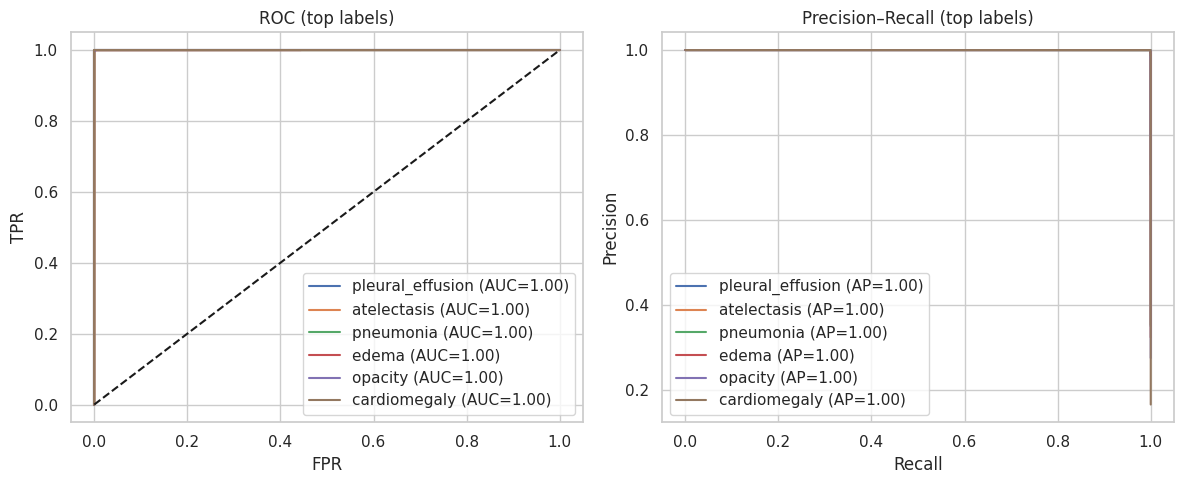

In [18]:
def plot_roc_pr(y_true_df, y_proba, labels, top_k=6, outpng='roc_pr_top_labels.png'):
    counts = y_true_df.sum().sort_values(ascending=False)
    top_labels = list(counts.index[:min(top_k, len(labels))])

    plt.figure(figsize=(12,5))

    # ROC
    plt.subplot(1,2,1)
    for lab in top_labels:
        i = labels.index(lab)
        try:
            fpr, tpr, _ = roc_curve(y_true_df[lab], y_proba[:, i])
            auc = roc_auc_score(y_true_df[lab], y_proba[:, i])
            plt.plot(fpr, tpr, label=f"{lab} (AUC={auc:.2f})")
        except Exception:
            pass
    plt.plot([0,1],[0,1],'k--')
    plt.title("ROC (top labels)"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()

    # PR
    plt.subplot(1,2,2)
    for lab in top_labels:
        i = labels.index(lab)
        try:
            prec, rec, _ = precision_recall_curve(y_true_df[lab], y_proba[:, i])
            ap = average_precision_score(y_true_df[lab], y_proba[:, i])
            plt.plot(rec, prec, label=f"{lab} (AP={ap:.2f})")
        except Exception:
            pass
    plt.title("Precision–Recall (top labels)"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend()

    plt.tight_layout()
    plt.savefig(outpng, dpi=200)
    plt.show()

plot_roc_pr(y_test.reset_index(drop=True), y_proba_bert, labels)


In [19]:
print("\n>>> Threshold tuning on validation set (maximize per-label F1)")

# get validation probabilities (BERT)
y_proba_val = get_bert_probs(X_val, tokenizer, model, device, batch_size=16)

best_t = {}
for i, lab in enumerate(labels):
    y_true = y_val.iloc[:, i].values
    probs  = y_proba_val[:, i]
    best_f1, best_thr = 0.0, 0.5
    for t in np.linspace(0.1, 0.9, 17):
        pred = (probs >= t).astype(int)
        f = f1_score(y_true, pred, zero_division=0)
        if f > best_f1:
            best_f1, best_thr = f, t
    best_t[lab] = best_thr

print("Best thresholds:", best_t)

# apply tuned thresholds to test set
y_pred_bert_tuned = np.zeros_like(y_proba_bert, dtype=int)
for i, lab in enumerate(labels):
    y_pred_bert_tuned[:, i] = (y_proba_bert[:, i] >= best_t[lab]).astype(int)

print("\nBERT classification report (tuned thresholds):")
print(classification_report(y_test, y_pred_bert_tuned, target_names=labels, zero_division=0))



>>> Threshold tuning on validation set (maximize per-label F1)


BERT inference: 100%|██████████| 893/893 [02:01<00:00,  7.36it/s]


Best thresholds: {'pneumonia': 0.25, 'cardiomegaly': 0.1, 'pleural_effusion': 0.1, 'atelectasis': 0.8, 'edema': 0.30000000000000004, 'infiltration': 0.8, 'nodule': 0.1, 'opacity': 0.2}

BERT classification report (tuned thresholds):
                  precision    recall  f1-score   support

       pneumonia       1.00      1.00      1.00      5010
    cardiomegaly       1.00      1.00      1.00      2381
pleural_effusion       1.00      1.00      1.00     10094
     atelectasis       1.00      1.00      1.00      5060
           edema       1.00      1.00      1.00      4636
    infiltration       1.00      1.00      1.00       339
          nodule       1.00      1.00      1.00       590
         opacity       1.00      1.00      1.00      3944

       micro avg       1.00      1.00      1.00     32054
       macro avg       1.00      1.00      1.00     32054
    weighted avg       1.00      1.00      1.00     32054
     samples avg       0.89      0.89      0.89     32054



In [21]:
test_texts = X_test.reset_index(drop=True)
ytest_df   = y_test.reset_index(drop=True)

eval_df = pd.DataFrame({'text': test_texts})
for i, lab in enumerate(labels):
    eval_df[f'true_{lab}'] = ytest_df.iloc[:, i].values
    eval_df[f'prob_{lab}'] = y_proba_bert[:, i]
    eval_df[f'pred_{lab}'] = y_pred_bert_tuned[:, i]

def mismatch_row(row):
    true = np.array([row[f'true_{l}'] for l in labels])
    pred = np.array([row[f'pred_{l}'] for l in labels])
    return not np.array_equal(true, pred)

eval_df['mismatch'] = eval_df.apply(mismatch_row, axis=1)
mismatches = eval_df[eval_df['mismatch']].copy()

def avg_wrong_pos_conf(row):
    true = np.array([row[f'true_{l}'] for l in labels])
    pred = np.array([row[f'pred_{l}'] for l in labels])
    prob = np.array([row[f'prob_{l}'] for l in labels])
    wrong_pos = (pred==1) & (true==0)
    return prob[wrong_pos].mean() if wrong_pos.any() else 0.0

mismatches['avg_wrong_conf'] = mismatches.apply(avg_wrong_pos_conf, axis=1)
top_hard = mismatches.sort_values('avg_wrong_conf', ascending=False).head(10)

print(f"Total mismatches: {len(mismatches)}\n\nTop 10 hard examples:")
for _, r in top_hard.iterrows():
    print("\n--- SAMPLE ---")
    print(r['text'][:400].replace('\n',' ') + " ...")
    print("True +:", [l for l in labels if r[f'true_{l}']==1])
    print("Pred +:", [l for l in labels if r[f'pred_{l}']==1])
    print("Probs≥0.3:", {l: float(r[f'prob_{l}']) for l in labels if r[f'prob_{l}']>=0.3})


Total mismatches: 30

Top 10 hard examples:

--- SAMPLE ---
ng tube repositioned tip ending distal gastric cavity right base opacification increased even thought might still atelectasis penumonia considered appropriate clinical setting right pleural effusion unchanged cardiomediastinal silhouette unchanged pneumothorax ...
True +: ['pleural_effusion', 'atelectasis']
Pred +: ['pneumonia', 'pleural_effusion', 'atelectasis']
Probs≥0.3: {'pneumonia': 0.9998630285263062, 'pleural_effusion': 0.9999725818634033, 'atelectasis': 0.9999740123748779}

--- SAMPLE ---
minimal leftward rotation endotracheal tube seen tip cm carina left picc line seen tip overlying midsvc ng tube seen tip projecting lower limit film rightsided pa catheter seen tip overlying right ventricular outflow tract also present right internal jugular central venous catheter tip overlying superior svc ekg lead seen corresponding wire projecting chest radiodense spring seen overlying right m ...
True +: ['cardiomegaly', 'pleural

In [22]:
outdir = "eval_outputs"
os.makedirs(outdir, exist_ok=True)

# tables
pd.DataFrame({
    'metric': ['hamming_loss','micro_f1','macro_f1','roc_auc_macro'],
    'Baseline':[hamming_loss(y_test, y_pred_baseline),
                f1_score(y_test, y_pred_baseline, average='micro', zero_division=0),
                f1_score(y_test, y_pred_baseline, average='macro', zero_division=0),
                np.nanmean([roc_auc_score(y_test.iloc[:,i], y_proba_baseline[:,i]) 
                            for i in range(len(labels))])]
}).to_csv(f"{outdir}/baseline_summary.csv", index=False)

pd.DataFrame({
    'metric': ['hamming_loss','micro_f1','macro_f1','roc_auc_macro'],
    'BERT@0.5':[hamming_loss(y_test, y_pred_bert),
                f1_score(y_test, y_pred_bert, average='micro', zero_division=0),
                f1_score(y_test, y_pred_bert, average='macro', zero_division=0),
                np.nanmean([roc_auc_score(y_test.iloc[:,i], y_proba_bert[:,i]) 
                            for i in range(len(labels))])],
    'BERT@tuned':[hamming_loss(y_test, y_pred_bert_tuned),
                  f1_score(y_test, y_pred_bert_tuned, average='micro', zero_division=0),
                  f1_score(y_test, y_pred_bert_tuned, average='macro', zero_division=0),
                  np.nanmean([roc_auc_score(y_test.iloc[:,i], y_proba_bert[:,i]) 
                              for i in range(len(labels))])]
}).to_csv(f"{outdir}/bert_summary.csv", index=False)

# reports
with open(f"{outdir}/classification_report_baseline.txt",'w') as f:
    f.write(classification_report(y_test, y_pred_baseline, target_names=labels, zero_division=0))
with open(f"{outdir}/classification_report_bert_05.txt",'w') as f:
    f.write(classification_report(y_test, y_pred_bert, target_names=labels, zero_division=0))
with open(f"{outdir}/classification_report_bert_tuned.txt",'w') as f:
    f.write(classification_report(y_test, y_pred_bert_tuned, target_names=labels, zero_division=0))

print("Saved artifacts to:", outdir)


Saved artifacts to: eval_outputs


In [23]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ==============================
# CONFIG (edit if you want)
# ==============================
SAVE_DIR = "conf_mats"       # folder to save confusion matrices
THRESHOLD = 0.5              # threshold if y_pred_bert contains probabilities
FIGSIZE = (4, 3)             # inches
DPI = 150

# =========================================================
# Helpers to sanitize file names and prepare aligned arrays
# =========================================================
def sanitize_filename(name: str) -> str:
    # remove anything problematic for file systems
    name = re.sub(r"[^\w\-]+", "_", name.strip())
    return re.sub(r"_+", "_", name).strip("_")

def to_numpy_and_align(y, labels=None, name="y"):
    """
    Convert y (np.array or pd.DataFrame) to numpy array [n_samples, n_labels].
    If DataFrame and labels is provided, reorder columns to match labels.
    If DataFrame and labels is None, infer labels from y.columns (and return them).
    """
    try:
        import pandas as pd
    except Exception:
        pd = None

    inferred_labels = None

    if pd is not None and isinstance(y, pd.DataFrame):
        if labels is None:
            inferred_labels = list(y.columns)
            y_np = y.to_numpy()
        else:
            # Ensure all requested labels are present
            missing = [c for c in labels if c not in y.columns]
            if missing:
                raise ValueError(
                    f"{name}: these labels are missing from DataFrame columns: {missing}\n"
                    f"Available columns: {list(y.columns)}"
                )
            y_np = y[labels].to_numpy()
    else:
        # assume numpy-like
        y_np = np.asarray(y)
        if labels is None:
            # create generic label names if none provided
            if y_np.ndim != 2:
                raise ValueError(f"{name} must be 2D if labels are not provided. Got shape {y_np.shape}.")
            inferred_labels = [f"Label_{i}" for i in range(y_np.shape[1])]

    return y_np, (labels if labels is not None else inferred_labels)

def binarize_if_needed(y_pred_np, threshold=0.5):
    """If predictions look like probabilities/logits, threshold them to {0,1}."""
    # If any value is not in {0,1}, treat as probabilities/logits
    if not np.array_equal(y_pred_np, y_pred_np.astype(bool)):
        # convert logits to probs if needed (heuristic)
        if y_pred_np.max() > 1 or y_pred_np.min() < 0:
            # looks like logits → apply sigmoid first
            y_pred_np = 1 / (1 + np.exp(-y_pred_np))
        y_bin = (y_pred_np >= threshold).astype(int)
        return y_bin
    return y_pred_np.astype(int)

def plot_and_save_cm(cm, class_name, save_path):
    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
    im = ax.imshow(cm, interpolation='nearest')
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No", "Yes"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["No", "Yes"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix - {class_name}")

    # Annotate counts
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    fig.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches="tight")
    plt.close(fig)

# =========================================================
# MAIN: Prepare data, compute & save confusion matrices
# =========================================================
def save_all_confusion_matrices(y_test, y_pred_bert, labels=None, threshold=THRESHOLD, save_dir=SAVE_DIR):
    # 1) Convert to numpy and align columns to labels (or infer labels)
    y_true_np, labels_aligned = to_numpy_and_align(y_test, labels, name="y_test")
    y_pred_np, _              = to_numpy_and_align(y_pred_bert, labels_aligned, name="y_pred_bert")

    # 2) Safety checks
    if y_true_np.shape != y_pred_np.shape:
        raise ValueError(
            f"Shape mismatch: y_test {y_true_np.shape} vs y_pred_bert {y_pred_np.shape}. "
            "Ensure both have [n_samples, n_labels] with the same label order."
        )

    # 3) Threshold predictions if not already binary
    y_pred_bin = binarize_if_needed(y_pred_np, threshold=threshold)

    # 4) Save per-class confusion matrices
    print("Available disease labels:", labels_aligned)
    os.makedirs(save_dir, exist_ok=True)

    for i, disease in enumerate(labels_aligned):
        cm = confusion_matrix(y_true_np[:, i], y_pred_bin[:, i], labels=[0, 1])
        fname = os.path.join(save_dir, f"conf_matrix_{sanitize_filename(disease)}.png")
        plot_and_save_cm(cm, disease, fname)
        print(f"✅ Saved: {fname}")

    # 5) Classification report
    print("\n=== Classification Report (multi-label) ===")
    print(classification_report(y_true_np, y_pred_bin, target_names=labels_aligned, zero_division=0))

    return labels_aligned

# ============================
# RUN (call the main function)
# ============================
# Example call (uses your existing y_test, y_pred_bert, and optional labels variables):
labels_aligned = save_all_confusion_matrices(y_test, y_pred_bert, labels=labels if 'labels' in globals() else None)


Available disease labels: ['pneumonia', 'cardiomegaly', 'pleural_effusion', 'atelectasis', 'edema', 'infiltration', 'nodule', 'opacity']
✅ Saved: conf_mats/conf_matrix_pneumonia.png
✅ Saved: conf_mats/conf_matrix_cardiomegaly.png
✅ Saved: conf_mats/conf_matrix_pleural_effusion.png
✅ Saved: conf_mats/conf_matrix_atelectasis.png
✅ Saved: conf_mats/conf_matrix_edema.png
✅ Saved: conf_mats/conf_matrix_infiltration.png
✅ Saved: conf_mats/conf_matrix_nodule.png
✅ Saved: conf_mats/conf_matrix_opacity.png

=== Classification Report (multi-label) ===
                  precision    recall  f1-score   support

       pneumonia       1.00      1.00      1.00      5010
    cardiomegaly       1.00      1.00      1.00      2381
pleural_effusion       1.00      1.00      1.00     10094
     atelectasis       1.00      1.00      1.00      5060
           edema       1.00      1.00      1.00      4636
    infiltration       1.00      1.00      1.00       339
          nodule       1.00      1.00      1.

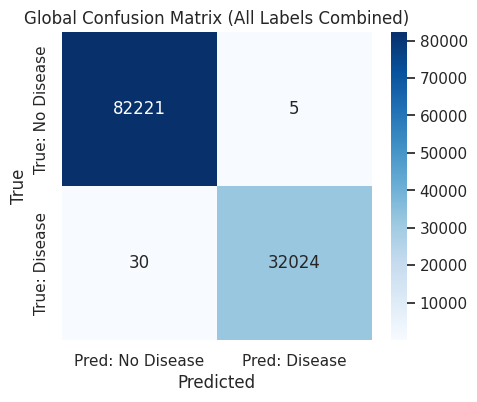

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming:
# y_test      → true labels (numpy array or DataFrame, shape [n_samples, n_labels])
# y_pred_bert → predicted labels (same shape, binary 0/1)
# labels      → list of disease names

# If predictions are probabilities, threshold at 0.5
if not np.array_equal(y_pred_bert, y_pred_bert.astype(bool)):
    y_pred_bert = (y_pred_bert >= 0.5).astype(int)

# Flatten everything into binary arrays
y_true_flat = y_test.to_numpy().ravel() if hasattr(y_test, "to_numpy") else y_test.ravel()
y_pred_flat = y_pred_bert.ravel()

# Compute single confusion matrix (global across all diseases)
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=[0, 1])

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No Disease", "Pred: Disease"],
            yticklabels=["True: No Disease", "True: Disease"])
plt.title("Global Confusion Matrix (All Labels Combined)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
